In [6]:
print("Hello World!")

Hello World!


In [ ]:
from datasets import load_dataset
import pandas as pd
from IPython.display import display
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns


ROOT = pathlib.Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
for p in [DATA_RAW, DATA_PROCESSED, MODELS]:
    p.mkdir(parents=True, exist_ok=True)

ds = load_dataset("reczoo/Avazu_x1")
split = "validation" if "validation" in ds else "train"
print(f"Using split: {split}")

sample = ds[split].shuffle(seed=42).select(range(100_000))
df = sample.to_pandas()
df.to_csv(DATA_PROCESSED / "avazu_sample_100k.csv", index=False)

print(" Sample saved to:", DATA_PROCESSED / "avazu_sample_100k.csv")


m:\Machine Learing Project\ML_project-CTR_Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
m:\Machine Learing Project\ML_project-CTR_Prediction\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kokom\.cache\huggingface\hub\datasets--reczoo--Avazu_x1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as a

In [ ]:
print("\n=== Info ===")
print(df.info())



=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   label    100000 non-null  int64
 1   feat_1   100000 non-null  int64
 2   feat_2   100000 non-null  int64
 3   feat_3   100000 non-null  int64
 4   feat_4   100000 non-null  int64
 5   feat_5   100000 non-null  int64
 6   feat_6   100000 non-null  int64
 7   feat_7   100000 non-null  int64
 8   feat_8   100000 non-null  int64
 9   feat_9   100000 non-null  int64
 10  feat_10  100000 non-null  int64
 11  feat_11  100000 non-null  int64
 12  feat_12  100000 non-null  int64
 13  feat_13  100000 non-null  int64
 14  feat_14  100000 non-null  int64
 15  feat_15  100000 non-null  int64
 16  feat_16  100000 non-null  int64
 17  feat_17  100000 non-null  int64
 18  feat_18  100000 non-null  int64
 19  feat_19  100000 non-null  int64
 20  feat_20  100000 non-null  int64
 21  feat_21  100000 non-

In [ ]:
print("Shape:", df.shape)
print("=== dtypes ===")
print(df.dtypes)

print("=== label distribution ===")
print(df["label"].value_counts(normalize=True))

Shape: (100000, 23)
=== dtypes ===
label      int64
feat_1     int64
feat_2     int64
feat_3     int64
feat_4     int64
feat_5     int64
feat_6     int64
feat_7     int64
feat_8     int64
feat_9     int64
feat_10    int64
feat_11    int64
feat_12    int64
feat_13    int64
feat_14    int64
feat_15    int64
feat_16    int64
feat_17    int64
feat_18    int64
feat_19    int64
feat_20    int64
feat_21    int64
feat_22    int64
dtype: object
=== label distribution ===
label
0    0.83175
1    0.16825
Name: proportion, dtype: float64


In [ ]:
pd.set_option('display.float_format', '{:.0f}'.format)
display(df.describe())

,label,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,feat_20,feat_21,feat_22
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,...,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
mean,0,1,9,60,3613,7907,7960,12998,13305,20239,...,1541007,1541155,1543495,1543504,1543558,1543946,1543956,1544026,1544194,1544257
std,0,0,0,161,147,1,159,4,1,32411,...,1,237,0,0,59,1,9,16,8,6
min,0,1,9,16,3580,7906,7930,12997,13304,13334,...,1541007,1541011,1543495,1543504,1543514,1543945,1543950,1544018,1544187,1544248
25%,0,1,9,17,3581,7906,7931,12997,13304,13335,...,1541007,1541027,1543495,1543504,1543519,1543945,1543950,1544018,1544188,1544252
50%,0,1,9,18,3582,7907,7931,12997,13304,13335,...,1541007,1541065,1543495,1543504,1543535,1543946,1543951,1544019,1544190,1544257
75%,0,1,10,33,3591,7908,7936,12998,13305,13335,...,1541007,1541177,1543495,1543504,1543574,1543946,1543958,1544025,1544196,1544262
max,1,7,15,3462,7893,7925,12926,13250,13329,291492,...,1541010,1543408,1543502,1543512,1543938,1543948,1544014,1544185,1544246,1544271


In [ ]:

print("\n=== Missing Values ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])



=== Missing Values ===
Series([], dtype: int64)


In [ ]:
print("\n=== Label Distribution ===")
print(df["label"].value_counts(normalize=True))



=== Label Distribution ===
label
0   1
1   0
Name: proportion, dtype: float64


C:\Users\A-plus\AppData\Local\Temp\ipykernel_3744\3489657371.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, hue=None, palette="viridis")


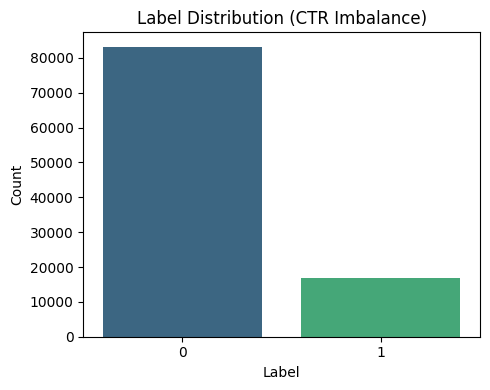

In [ ]:

FIGURES = pathlib.Path.cwd() / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(5,4))
sns.countplot(x="label", data=df, hue=None, palette="viridis")
plt.title("Label Distribution (CTR Imbalance)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES / "label_distribution.png", dpi=300)
plt.show()

In [ ]:
label_dist = df["label"].value_counts(normalize=True)
neg, pos = label_dist.get(0, 0) * 100, label_dist.get(1, 0) * 100

print(f"\n📉 Dataset Imbalance: Class 0 = {neg:.2f}%, Class 1 = {pos:.2f}%")

print("\n✅ EDA complete! Figures saved in:", FIGURES)



📉 Dataset Imbalance: Class 0 = 83.17%, Class 1 = 16.83%

✅ EDA complete! Figures saved in: d:\projects\Ai\ML_project-CTR_Prediction\notebooks\reports\figures
